In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from utils_yose import  outliers_detection, QQPlot, log_transform, add_engineered_features, fill_domain_na, map_ordinal_categories, build_preprocessor, plot_hist_per_columns, plot_feature_correlations

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor as lgbm

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: '%.5f' % x)

Note: you may need to restart the kernel to use updated packages.


In [2]:
train_data = "../data/train.csv"
test_data = "../data/test.csv"
df_train = pd.read_csv(train_data)

## Data Engineering

In [3]:
df_train = add_engineered_features(df_train)
df_train = fill_domain_na(df_train)
df_train = map_ordinal_categories(df_train)

## Pre - Process data

In [4]:
"""df_train_cat = df_train.select_dtypes(include=['object'])
try:
    df_train_cat_dummies = pd.get_dummies(df_train_cat, drop_first=True)
    for col in df_train_cat_dummies.columns:
        df_train_cat_dummies[col] = df_train_cat_dummies[col].astype(int)
except Exception:
    pass

df_train_num = df_train.select_dtypes(include=['float64', 'int64'])

df_train = pd.concat([df_train_num, df_train_cat_dummies], axis=1)
df_train.index = df_train.pop('Id')"""

"df_train_cat = df_train.select_dtypes(include=['object'])\ntry:\n    df_train_cat_dummies = pd.get_dummies(df_train_cat, drop_first=True)\n    for col in df_train_cat_dummies.columns:\n        df_train_cat_dummies[col] = df_train_cat_dummies[col].astype(int)\nexcept Exception:\n    pass\n\ndf_train_num = df_train.select_dtypes(include=['float64', 'int64'])\n\ndf_train = pd.concat([df_train_num, df_train_cat_dummies], axis=1)\ndf_train.index = df_train.pop('Id')"

In [5]:
X = df_train.drop("SalePrice", axis=1)
y = df_train["SalePrice"]
y = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = build_preprocessor(X_train)
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)



try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    feature_names = [f"feat_{i}" for i in range(X_train_proc.shape[1])]


df_train_processed = pd.DataFrame(
    X_train_proc,
    columns=feature_names,
    index=X_train.index
)

# Agregar la y como columna
df_train_processed["SalePrice"] = y_train.values

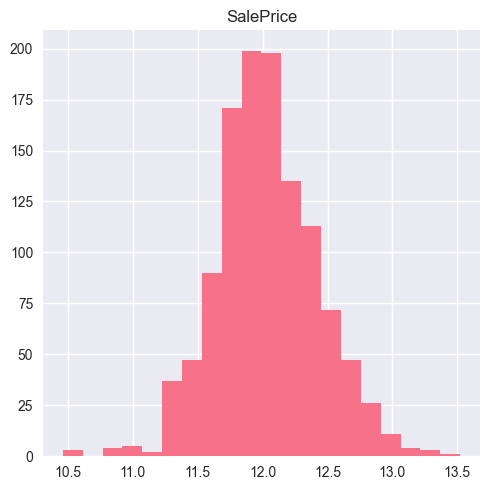

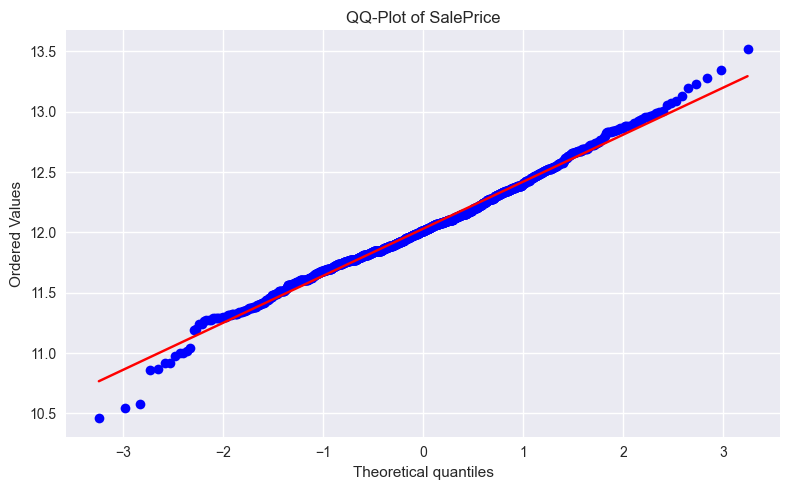

In [6]:
plot_hist_per_columns(df_train_processed, 'SalePrice')
QQPlot(df_train_processed['SalePrice'])

In [7]:
df_train_processed['SalePrice'] = log_transform(df_train_processed['SalePrice'])

### Post Log transform

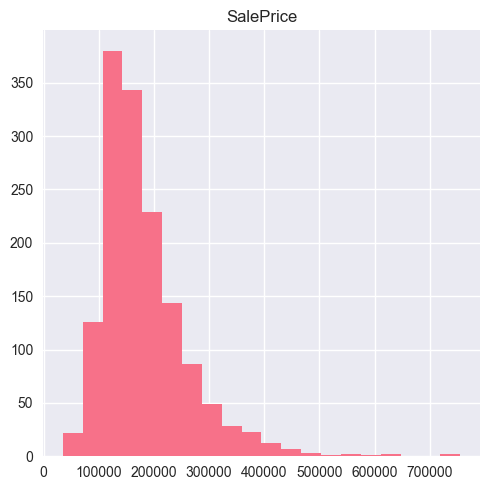

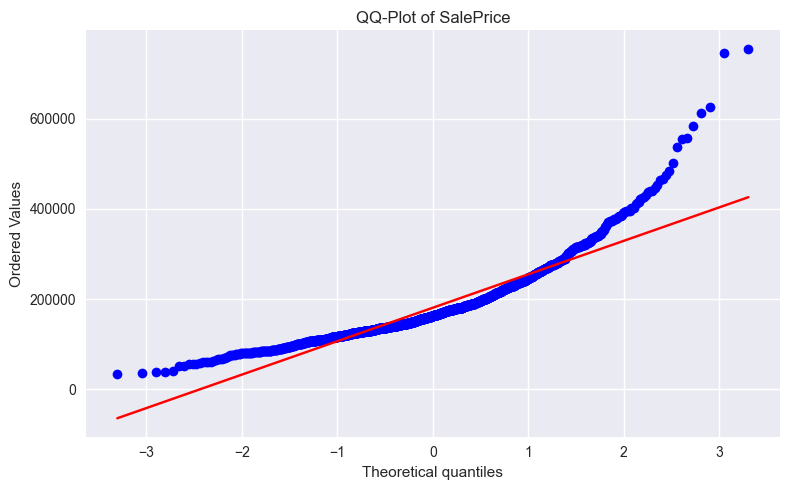

In [8]:
plot_hist_per_columns(df_train, 'SalePrice')
QQPlot(df_train['SalePrice'])

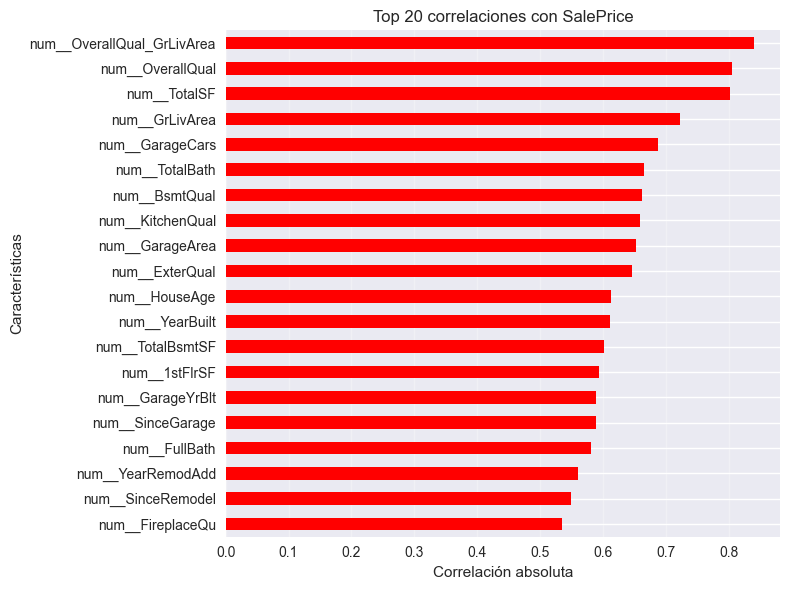

In [9]:
corr = df_train_processed.corr()['SalePrice'].sort_values(ascending=False).drop('SalePrice')
corr_abs = corr.abs().sort_values(ascending=False)
corr_abs_selected = corr_abs[corr_abs > 0.5]

plot_feature_correlations(df_train_processed.drop('SalePrice', axis=1), df_train_processed['SalePrice']);

In [10]:
for col in corr_abs_selected.index:
    outliers_vals = outliers_detection(df_train_processed[col])
    if outliers_vals:
        mask = df_train_processed[col].isin(outliers_vals)
        df_train_processed.loc[mask, col] = df_train_processed[col].median()

sp_outliers = outliers_detection(df_train['SalePrice'])
if sp_outliers:
    sp_mask = df_train_processed['SalePrice'].isin(sp_outliers)
    df_train_processed.loc[sp_mask, 'SalePrice'] = df_train_processed['SalePrice'].median()

print("Outliers encontrados y tratados con la mediana.")

Outliers encontrados y tratados con la mediana.


In [11]:
df_train_processed['SalePrice'].mean()

np.float64(2.566856390406571)

In [12]:
print("Mean of SalesPrice:",float(np.exp(df_train_processed['SalePrice']).mean()))
print("Standard Deviation of SalesPrice:",float(np.exp(df_train_processed['SalePrice']).std()))

Mean of SalesPrice: 13.030658310971575
Standard Deviation of SalesPrice: 0.39060602031704306


## OLS

In [13]:
X_ = sm.add_constant(X_train_proc)
model = sm.OLS(y_train, X_train_proc).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     67.81
Date:                Sat, 23 Aug 2025   Prob (F-statistic):               0.00
Time:                        02:04:31   Log-Likelihood:                 1144.0
No. Observations:                1168   AIC:                            -1808.
Df Residuals:                     928   BIC:                            -592.8
Df Model:                         239                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0008      0.003      0.226      0.8

In [14]:
columnas_significativas = model.pvalues < 0.05 
columnas_significativas = columnas_significativas[columnas_significativas].index

## Ridge

In [15]:
np.random.seed(42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_proc, y_train)

y_pred = ridge.predict(X_test_proc)

print("Mean squared error: %.5f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: % 5f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("Coefficient of determination: %.5f" % r2_score(y_test, y_pred))

Mean squared error: 0.01577
Root mean squared error:  0.125592
Coefficient of determination: 0.91548


### Cross - Validation

In [16]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-3, 3, 10))
ridge.fit(X_train_proc, y_train)
ridge.alpha_

y_pred = ridge.predict(X_test_proc)

print("Mean squared error: %.5f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: % 5f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("Coefficient of determination: %.5f" % r2_score(y_test, y_pred))

Mean squared error: 0.01692
Root mean squared error:  0.130093
Coefficient of determination: 0.90931


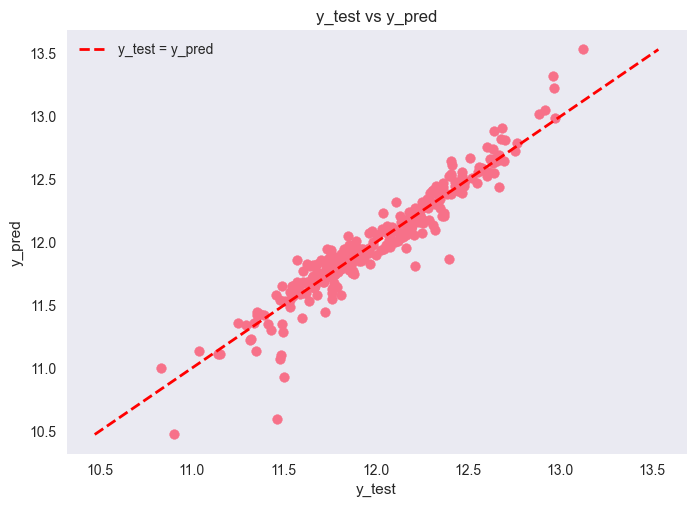

In [17]:
plt.scatter(y_pred, y_test) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y_test = y_pred')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('y_test vs y_pred')
plt.grid()
plt.legend()
plt.show()

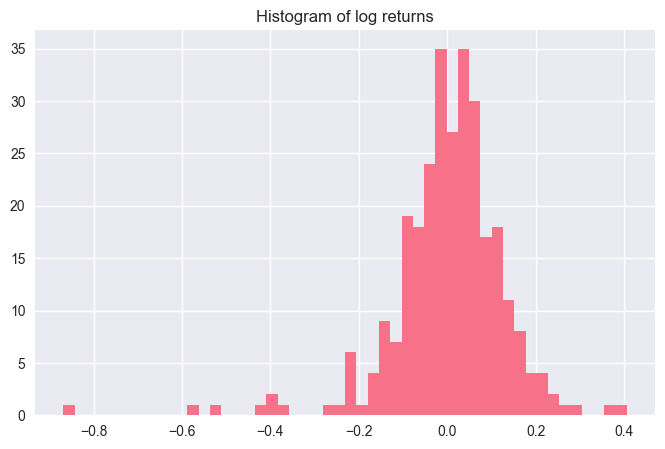

In [18]:
log_returns = pd.DataFrame(columns=['log_returns'], index= y_test.index)
log_returns['log_returns'] = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(log_returns, bins=50)
plt.title('Histogram of log returns')
plt.grid(1)
plt.show()

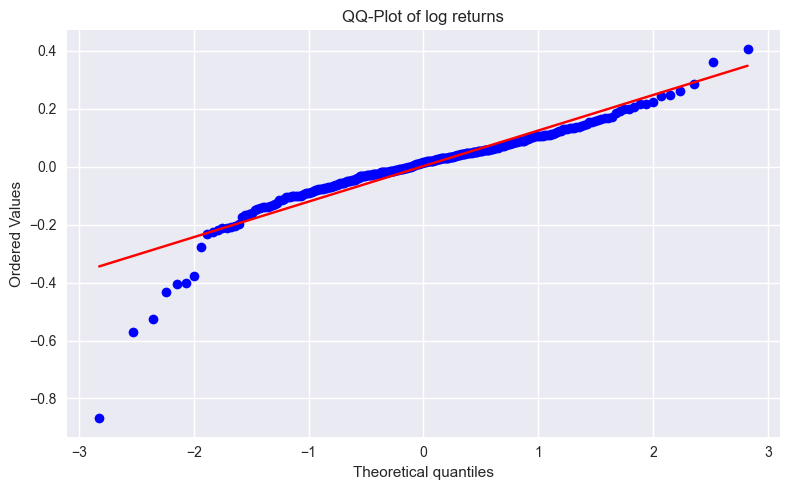

In [19]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

serie = np.asarray(log_returns).ravel()
serie = serie[~np.isnan(serie)]

plt.figure(figsize=(8,5))
stats.probplot(serie, dist='norm', plot=plt)
plt.grid(True)
plt.title('QQ-Plot of log returns')
plt.tight_layout()
plt.show()

## Random Forest Regressor

In [20]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_proc, y_train)

y_pred = rf.predict(X_test_proc)

print("Mean squared error: %.5f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: % 5f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("Coefficient of determination: %.5f" % r2_score(y_test, y_pred))

Mean squared error: 0.02143
Root mean squared error:  0.146392
Coefficient of determination: 0.88516


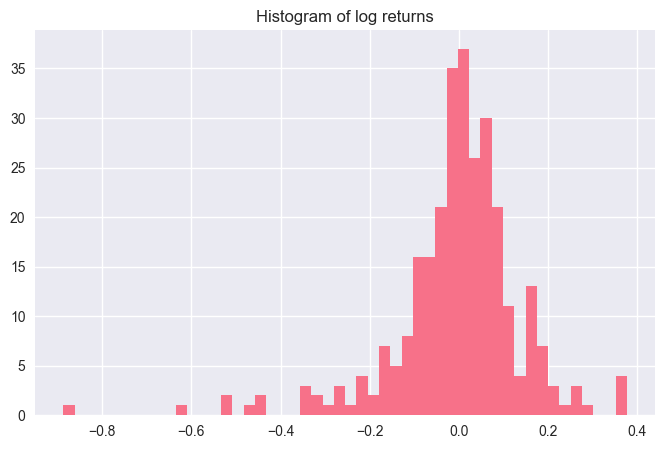

In [21]:
log_returns = pd.DataFrame(columns=['log_returns'], index= y_test.index)
log_returns['log_returns'] = y_test - y_pred

log_returns_no_outliers = log_returns[~log_returns['log_returns'].isin(outliers_detection(log_returns['log_returns']))]

plt.figure(figsize=(8,5))
plt.hist(log_returns, bins=50)
plt.title('Histogram of log returns')
plt.grid(1)
plt.show()

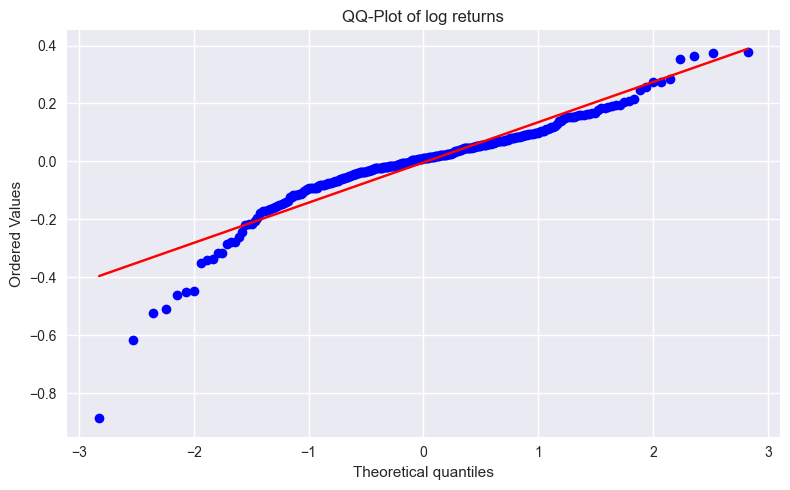

In [22]:
serie = np.asarray(log_returns).ravel()
serie = serie[~np.isnan(serie)]

plt.figure(figsize=(8,5))
stats.probplot(serie, dist='norm', plot=plt)
plt.grid(True)
plt.title('QQ-Plot of log returns')
plt.tight_layout()
plt.show()

## PIPELINE con validación

In [23]:

X_train, X_valid, y_train, y_valid = train_test_split(df_train.drop(["SalePrice", 'Id'], axis=1), y, test_size=0.2, random_state=42)
pre = build_preprocessor(X_train)
pre.fit(X_train)

pipe_lasso = Pipeline([
    ("pre", clone(pre)),
    ("model", Lasso(alpha=0.0005, max_iter=5000, random_state=42))
])

pipe_rf = Pipeline([
    ("pre", clone(pre)),
    ("model", RandomForestRegressor(
        n_estimators=600, max_features="sqrt", random_state=42, n_jobs=-1
    ))
])

pipe_lgbm = Pipeline([
    ("pre", clone(pre)),
    ("model", lgbm(
        n_estimators=3000, learning_rate=0.03, max_depth=-1,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    ))
])

pipe_lasso.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_lgbm.fit(X_train, y_train)

p_lasso = pipe_lasso.predict(X_valid)
p_rf    = pipe_rf.predict(X_valid)
p_lgbm  = pipe_lgbm.predict(X_valid)

p_ens = (p_lasso + p_rf + p_lgbm) / 3

rmse = np.sqrt(mean_squared_error(y_valid, p_ens))
print(f"RMSE ensemble: {rmse:,.5f}")
print(f"R2 ensemble  : {r2_score(y_valid, p_ens):.5f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4266
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 184
[LightGBM] [Info] Start training from score 12.030658
RMSE ensemble: 0.13023
R2 ensemble  : 0.90911


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
r2_scores = []
trained_models = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_valid_fold = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_train_fold, y_valid_fold = y_train.iloc[train_idx], y_train.iloc[valid_idx]

    pre_fold = build_preprocessor(X_train_fold)
    pre_fold.fit(X_train_fold)

    pipe_lasso_fold = Pipeline([
        ("pre", clone(pre_fold)),
        ("model", Lasso(alpha=0.0005, max_iter=5000, random_state=42))
    ])
    pipe_rf_fold = Pipeline([
        ("pre", clone(pre_fold)),
        ("model", RandomForestRegressor(
            n_estimators=600, max_features="sqrt", random_state=42, n_jobs=-1
        ))
    ])
    pipe_lgbm_fold = Pipeline([
        ("pre", clone(pre_fold)),
        ("model", lgbm(
            n_estimators=3000, learning_rate=0.03, max_depth=-1,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1
        ))
    ])

    pipe_lasso_fold.fit(X_train_fold, y_train_fold)
    pipe_rf_fold.fit(X_train_fold, y_train_fold)
    pipe_lgbm_fold.fit(X_train_fold, y_train_fold)

    p_lasso_fold = pipe_lasso_fold.predict(X_valid_fold)
    p_rf_fold    = pipe_rf_fold.predict(X_valid_fold)
    p_lgbm_fold  = pipe_lgbm_fold.predict(X_valid_fold)

    p_ens_fold = (p_lasso_fold + p_rf_fold + p_lgbm_fold) / 3

    rmse_fold = np.sqrt(mean_squared_error(y_valid_fold, p_ens_fold))
    r2_fold = r2_score(y_valid_fold, p_ens_fold)
    
    rmse_scores.append(rmse_fold)
    r2_scores.append(r2_fold)

    trained_models.append({
        'lasso': pipe_lasso_fold,
        'rf': pipe_rf_fold,
        'lgbm': pipe_lgbm_fold
    })

    print(f"Fold {fold+1}: RMSE = {rmse_fold:,.5f}, R2 = {r2_fold:.5f}")

best_fold_index = np.argmin(rmse_scores)
best_rmse = rmse_scores[best_fold_index]
best_r2 = r2_scores[best_fold_index]

best_models = trained_models[best_fold_index]
best_pipe_lasso = best_models['lasso']
best_pipe_rf = best_models['rf']
best_pipe_lgbm = best_models['lgbm']

print("\n---")
print(f"Mejor fold: {best_fold_index + 1}")
print(f"RMSE del mejor fold: {best_rmse:,.5f}")
print(f"R2 del mejor fold  : {best_r2:.5f}")
print("\nLos modelos del mejor fold están guardados en las variables 'best_pipe_lasso', 'best_pipe_rf', y 'best_pipe_lgbm'.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4013
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 176
[LightGBM] [Info] Start training from score 12.030005
Fold 1: RMSE = 0.12525, R2 = 0.90486
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4020
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 176
[LightGBM] [Info] Start training from score 12.034848
Fold 2: RMSE = 0.12378, R2 = 0.90214
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002042 seconds.
You can se

# Submission RandomForest

In [25]:
df_submission = pd.read_csv(test_data, index_col="Id")

def make_features(df):
    df = add_engineered_features(df)
    df = fill_domain_na(df)
    df = map_ordinal_categories(df)
    return df

X_submit_fe = make_features(df_submission.copy())

X_submit_fe = X_submit_fe.assign(Id=X_submit_fe.index)

X_submit_proc = preprocessor.transform(X_submit_fe)

y_pred_submission = rf.predict(X_submit_proc)
y_pred_submission = np.expm1(y_pred_submission)

submission = pd.DataFrame({"Id": df_submission.index, "SalePrice": y_pred_submission})
submission.to_csv("submission.csv", index=False)

In [26]:
id = df_submission.index.to_numpy().astype(int) 

df_submission = pd.DataFrame({'Id': id, 'SalePrice': y_pred_submission})
#df_submission.to_csv('../data/submission.csv', index=False)
df_submission

,Id,SalePrice
0,1461,120541.29731
1,1462,156606.04662
2,1463,179269.71726
3,1464,182437.69968
4,1465,198910.06720
...,...,...
1454,2915,94518.88924
1455,2916,93698.04305
1456,2917,157872.00715
1457,2918,121440.16773


# Submission pipeline with ensemble

In [27]:
df_submission = pd.read_csv(test_data, index_col="Id")

def make_features(df):
    df = add_engineered_features(df)
    df = fill_domain_na(df)
    df = map_ordinal_categories(df)
    return df

X_submit_fe = make_features(df_submission.copy())

X_submit_fe = X_submit_fe.assign(Id=X_submit_fe.index)

pred_lasso = pipe_lasso.predict(X_submit_fe)
pred_rf    = pipe_rf.predict(X_submit_fe)
pred_lgbm  = pipe_lgbm.predict(X_submit_fe)

y_pred_submission = (pred_lasso + pred_rf + pred_lgbm) / 3

y_pred_submission = np.expm1(y_pred_submission)

submission = pd.DataFrame({
    "Id": df_submission.index,
    "SalePrice": y_pred_submission
})
submission.to_csv("submission.csv", index=False)

submission_alt = submission.copy()
submission_alt["Id"] = submission_alt["Id"].astype(int)
submission_alt.to_csv("../data/submission.csv", index=False)

submission.head()

,Id,SalePrice
0,1461,119565.23937
1,1462,160002.71114
2,1463,184988.26878
3,1464,190422.44131
4,1465,197654.30478


# BEST FOLDS!!!

In [ ]:
df_submission = pd.read_csv(test_data, index_col="Id")

def make_features(df):
    df = add_engineered_features(df)
    df = fill_domain_na(df)
    df = map_ordinal_categories(df)
    return df

X_submit_fe = make_features(df_submission.copy())
X_submit_fe = X_submit_fe.assign(Id=X_submit_fe.index)

pred_lasso = best_pipe_lasso.predict(X_submit_fe)
pred_rf    = best_pipe_rf.predict(X_submit_fe)
pred_lgbm  = best_pipe_lgbm.predict(X_submit_fe)

y_pred_submission = (pred_lasso + pred_rf + pred_lgbm) / 3

y_pred_submission = np.expm1(y_pred_submission)

submission = pd.DataFrame({
    "Id": df_submission.index,
    "SalePrice": y_pred_submission
})
submission.to_csv("submission.csv", index=False)

submission_alt = submission.copy()
submission_alt["Id"] = submission_alt["Id"].astype(int)
submission_alt.to_csv("../data/submission3pipes.csv", index=False)

print(submission.head())

Archivo de envío 'submission.csv' creado con éxito.
Las primeras 5 filas del archivo de envío son:
     Id    SalePrice
0  1461 122445.06152
1  1462 159078.85401
2  1463 185784.00799
3  1464 191532.92579
4  1465 195826.52797


# Locura total

In [32]:
# Create the KFold object. Let's use 5 splits.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store the metrics and models for each fold
rmse_scores = []
r2_scores = []
trained_models = []

# Loop through each fold
for fold, (train_idx, valid_idx) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_valid_fold = X_train.iloc[train_idx], X_train.iloc[valid_idx]
    y_train_fold, y_valid_fold = y_train.iloc[train_idx], y_train.iloc[valid_idx]

    # Preprocessor fitting and cloning
    pre_fold = build_preprocessor(X_train_fold)
    pre_fold.fit(X_train_fold)

    # Initialize and train the pipelines for the current fold
    pipe_lasso_fold = Pipeline([
        ("pre", clone(pre_fold)),
        ("model", Lasso(alpha=0.0005, max_iter=5000, random_state=42))
    ])
    pipe_rf_fold = Pipeline([
        ("pre", clone(pre_fold)),
        ("model", RandomForestRegressor(
            n_estimators=600, max_features="sqrt", random_state=42, n_jobs=-1
        ))
    ])
    pipe_lgbm_fold = Pipeline([
        ("pre", clone(pre_fold)),
        ("model", lgbm(
            n_estimators=3000, learning_rate=0.03, max_depth=-1,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1
        ))
    ])
    # NEW: XGBoost Pipeline
    pipe_xgb_fold = Pipeline([
        ("pre", clone(pre_fold)),
        ("model", xgb.XGBRegressor(
            n_estimators=3000, learning_rate=0.03, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1
        ))
    ])
    # NEW: CatBoost Pipeline
    pipe_cat_fold = Pipeline([
        ("pre", clone(pre_fold)),
        ("model", CatBoostRegressor(
            n_estimators=3000, learning_rate=0.03,
            subsample=0.8,
            random_state=42, verbose=0
        ))
    ])

    # Fit all five pipelines
    pipe_lasso_fold.fit(X_train_fold, y_train_fold)
    pipe_rf_fold.fit(X_train_fold, y_train_fold)
    pipe_lgbm_fold.fit(X_train_fold, y_train_fold)
    pipe_xgb_fold.fit(X_train_fold, y_train_fold)
    pipe_cat_fold.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation data for the current fold
    p_lasso_fold = pipe_lasso_fold.predict(X_valid_fold)
    p_rf_fold    = pipe_rf_fold.predict(X_valid_fold)
    p_lgbm_fold  = pipe_lgbm_fold.predict(X_valid_fold)
    p_xgb_fold   = pipe_xgb_fold.predict(X_valid_fold)
    p_cat_fold   = pipe_cat_fold.predict(X_valid_fold)

    # Ensemble the predictions (now with 5 models)
    p_ens_fold = (p_lasso_fold + p_rf_fold + p_lgbm_fold + p_xgb_fold + p_cat_fold) / 5

    # Calculate and store the metrics
    rmse_fold = np.sqrt(mean_squared_error(y_valid_fold, p_ens_fold))
    r2_fold = r2_score(y_valid_fold, p_ens_fold)
    
    rmse_scores.append(rmse_fold)
    r2_scores.append(r2_fold)

    # Store the models for this fold
    trained_models.append({
        'lasso': pipe_lasso_fold,
        'rf': pipe_rf_fold,
        'lgbm': pipe_lgbm_fold,
        'xgb': pipe_xgb_fold,
        'cat': pipe_cat_fold
    })

    print(f"Fold {fold+1}: RMSE = {rmse_fold:,.5f}, R2 = {r2_fold:.5f}")

# Find the best fold based on the minimum RMSE
best_fold_index = np.argmin(rmse_scores)
best_rmse = rmse_scores[best_fold_index]
best_r2 = r2_scores[best_fold_index]

# Retrieve the models from the best fold
best_models = trained_models[best_fold_index]
best_pipe_lasso = best_models['lasso']
best_pipe_rf = best_models['rf']
best_pipe_lgbm = best_models['lgbm']
best_pipe_xgb = best_models['xgb']
best_pipe_cat = best_models['cat']

print("\n---")
print(f"Mejor fold: {best_fold_index + 1}")
print(f"RMSE del mejor fold: {best_rmse:,.5f}")
print(f"R2 del mejor fold  : {best_r2:.5f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4013
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 176
[LightGBM] [Info] Start training from score 12.030005
Fold 1: RMSE = 0.12384, R2 = 0.90699
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002487 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4020
[LightGBM] [Info] Number of data points in the train set: 934, number of used features: 176
[LightGBM] [Info] Start training from score 12.034848
Fold 2: RMSE = 0.12526, R2 = 0.89979
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002733 seconds.
You can se

In [33]:
df_submission = pd.read_csv(test_data, index_col="Id")

def make_features(df):
    df = add_engineered_features(df)
    df = fill_domain_na(df)
    df = map_ordinal_categories(df)
    return df

X_submit_fe = make_features(df_submission.copy())
X_submit_fe = X_submit_fe.assign(Id=X_submit_fe.index)

pred_lasso = best_pipe_lasso.predict(X_submit_fe)
pred_rf    = best_pipe_rf.predict(X_submit_fe)
pred_lgbm  = best_pipe_lgbm.predict(X_submit_fe)
pred_xgb   = best_pipe_xgb.predict(X_submit_fe)
pred_cat   = best_pipe_cat.predict(X_submit_fe)

y_pred_submission = (pred_lasso + pred_rf + pred_lgbm + pred_xgb + pred_cat) / 5

y_pred_submission = np.expm1(y_pred_submission)

submission = pd.DataFrame({
    "Id": df_submission.index,
    "SalePrice": y_pred_submission
})
submission.to_csv("submission.csv", index=False)

submission_alt = submission.copy()
submission_alt["Id"] = submission_alt["Id"].astype(int)
submission_alt.to_csv("../data/submission5pipes.csv", index=False)

print(submission.head())

     Id    SalePrice
0  1461 122628.85727
1  1462 159785.96825
2  1463 184131.27921
3  1464 193569.95276
4  1465 194678.29966
